# Oxford-IIIT Pet: Feature Extraction y Transfer Learning 🐶🐱

Bienvenidos al Parcial 3. A partir de hoy, nuestro código será tratado con **estándares de producción**. Como Ingenieros/Científicos Senior, ya no escribiremos *montañas de código* en nuestras libretas. Toda la ingeniería de datos, módulos de arquitectura (PyTorch Lightning) y graficadores complejos han sido abstraídos a scripts dedicados (`data.py`, `models.py`, `viz.py`). 

Nuestra libreta funcionará como debe ser: un punto de ejecución y documentación que demuestra cómo armar el rompecabezas paso a paso.

In [1]:
import torch
import pytorch_lightning as pl

# Nuestros Helpers Modulares (¡Adiós código sucio!)
from data import get_pet_data
from models import TransferLearningPetModel
from viz import show_images_batch, plot_pca_features

pl.seed_everything(42) # Reproducibilidad ante todo

Seed set to 42


42

## 1. Cargar y Explorar Atentamente los Datos
El dataset consiste en 37 categorías (razas) diferentes. Usamos la función abstraída `get_pet_data` que internamente aplica los estándares de normalización exigidos por ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229...`).

Descargando/Verificando dataset OxfordIIITPet...


100%|██████████| 792M/792M [04:04<00:00, 3.24MB/s] 
100%|██████████| 19.2M/19.2M [00:05<00:00, 3.63MB/s]
c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


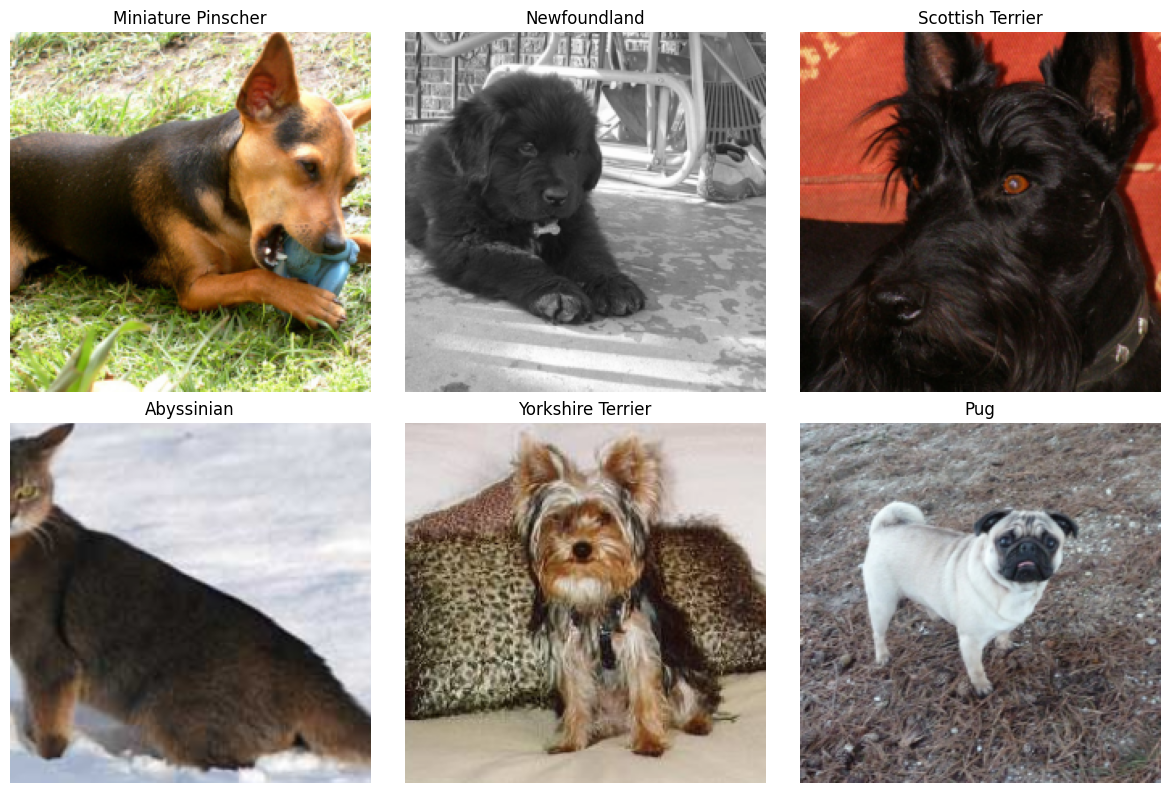

In [2]:
train_loader, val_loader, class_names = get_pet_data(data_dir='./data', batch_size=32)

# Extraemos un lote para verlo
images, labels = next(iter(train_loader))
show_images_batch(images, labels, class_names, max_images=6)

## 2. Feature Extraction: ¿Qué sabe ya una CNN?
Antes de hacer *Fine-Tuning* para clasificar exactamente el tipo de Pug o Bulldog, veamos qué es lo que una red pre-entrenada con ImageNet (`EfficientNet-v2-s`) extrae de estas imágenes en su última capa, justo antes de intentar clasificar.

¡Nota lo fácil que es instanciar la red cuando usamos Pytorch Lightning en un script adjunto!

In [3]:
# Usamos efficientnet_v2_s por su altísima velocidad de convergencia.
# Bajo el capó en models.py, se usa siempre models.EfficientNet_V2_S_Weights.DEFAULT.
model = TransferLearningPetModel(model_name='efficientnet_v2_s', num_classes=37, freeze_backbone=True)
model.eval()

# Extraemos los embeddings (features vector) de este batch
with torch.no_grad():
    features = model.extract_features(images).numpy()
    labels_np = labels.numpy()

print(f"El vector de características para cada imagen tiene tamaño: {features.shape}")

El vector de características para cada imagen tiene tamaño: (32, 1280)


## 3. Magia Pura: PCA en 3D (Show, Don't Tell)
Ese vector grandísimo de características es imposible de entender por un humano. Reduzcámoslo a 3 dimensiones con PCA y usemos nuestro helper interactivo en Plotly. 
Verás de inmediato que sin haber enseñado al modelo las nuevas razas, la red por sí sola agrupa en "islas" distintas a los felinos de los caninos basándose únicamente en sus texturas aprendidas previamente.

In [4]:
plot_pca_features(features, labels_np, class_names, n_components=3)

## 4. Fine-Tuning de la Capa Final
Como nuestra meta no es solo separar grandes grupos, sino diferenciar al Pug del Bulldog Francés con precisión industrial, usaremos PyTorch Lightning para re-entrenar (Fine-Tune) nuestra última capa recién añadida.

In [5]:
# Debido a Lightning, nuestro bucle de entrenamiento se reduce a esto:
trainer = pl.Trainer(max_epochs=3, 
                     accelerator='auto', # Toma GPU si en Windows hay CUDA, sino CPU
                     devices=1,
                     enable_progress_bar=True)

# Correr esta línea ejecutará todo el entrenamiento de la nueva capa
trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: UserWarning:

Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.

c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL cla

Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.

